# Method of Moments Estimators for the Gamma Distribution
### Are they biased or unbiased?

**Gamma Distribution** with shape $k$ and scale $\theta$:
- Mean: $\mu = k\theta$
- Variance: $\sigma^2 = k\theta^2$

**Method of Moments (MOM) Estimators** — solve by setting sample moments equal to population moments:

$$\hat{\theta} = \frac{s^2}{\bar{x}}, \qquad \hat{k} = \frac{\bar{x}^2}{s^2}$$

where $\bar{x}$ is the sample mean and $s^2$ is the sample variance.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

ModuleNotFoundError: No module named 'numpy'

## 1. MOM Estimator Function

In [3]:
def mom_estimators(sample):
    """
    Compute MOM estimators for Gamma(k, theta) from a sample.
    Returns estimated shape k_hat and scale theta_hat.
    """
    x_bar = np.mean(sample)
    s2    = np.var(sample, ddof=1)   # unbiased sample variance
    theta_hat = s2 / x_bar
    k_hat     = x_bar ** 2 / s2
    return k_hat, theta_hat

## 2. Simulation

In [4]:
# True parameters
k_true     = 3.0
theta_true = 2.0

# Simulation settings
n_simulations = 10000
sample_sizes  = [10, 30, 100, 500]

results = {}

for n in sample_sizes:
    k_estimates     = []
    theta_estimates = []

    for _ in range(n_simulations):
        # numpy uses shape=k, scale=theta
        sample = np.random.gamma(shape=k_true, scale=theta_true, size=n)
        k_hat, theta_hat = mom_estimators(sample)
        k_estimates.append(k_hat)
        theta_estimates.append(theta_hat)

    results[n] = {
        'k_mean':     np.mean(k_estimates),
        'k_std':      np.std(k_estimates),
        'theta_mean': np.mean(theta_estimates),
        'theta_std':  np.std(theta_estimates),
        'k_bias':     np.mean(k_estimates) - k_true,
        'theta_bias': np.mean(theta_estimates) - theta_true,
        'k_all':      k_estimates,
        'theta_all':  theta_estimates
    }

## 3. Bias Summary Table

In [8]:
print(f"True parameters: k = {k_true}, theta = {theta_true}")
print(f"Number of simulations: {n_simulations}")
print()
print(f"{'n':>6} | {'E[k_hat]':>10} | {'Bias(k)':>10} | {'E[theta_hat]':>13} | {'Bias(theta)':>12}")
print("-" * 65)

for n in sample_sizes:
    r = results[n]
    print(f"{n:>6} | {r['k_mean']:>10.4f} | {r['k_bias']:>10.4f} | "
          f"{r['theta_mean']:>13.4f} | {r['theta_bias']:>12.4f}")

True parameters: k = 3.0, theta = 2.0
Number of simulations: 10000

     n |   E[k_hat] |    Bias(k) |  E[theta_hat] |  Bias(theta)
-----------------------------------------------------------------
    10 |     4.0134 |     1.0134 |        1.9250 |      -0.0750
    30 |     3.2976 |     0.2976 |        1.9838 |      -0.0162
   100 |     3.0830 |     0.0830 |        1.9978 |      -0.0022
   500 |     3.0196 |     0.0196 |        1.9974 |      -0.0026


## 4. Visualize Sampling Distributions

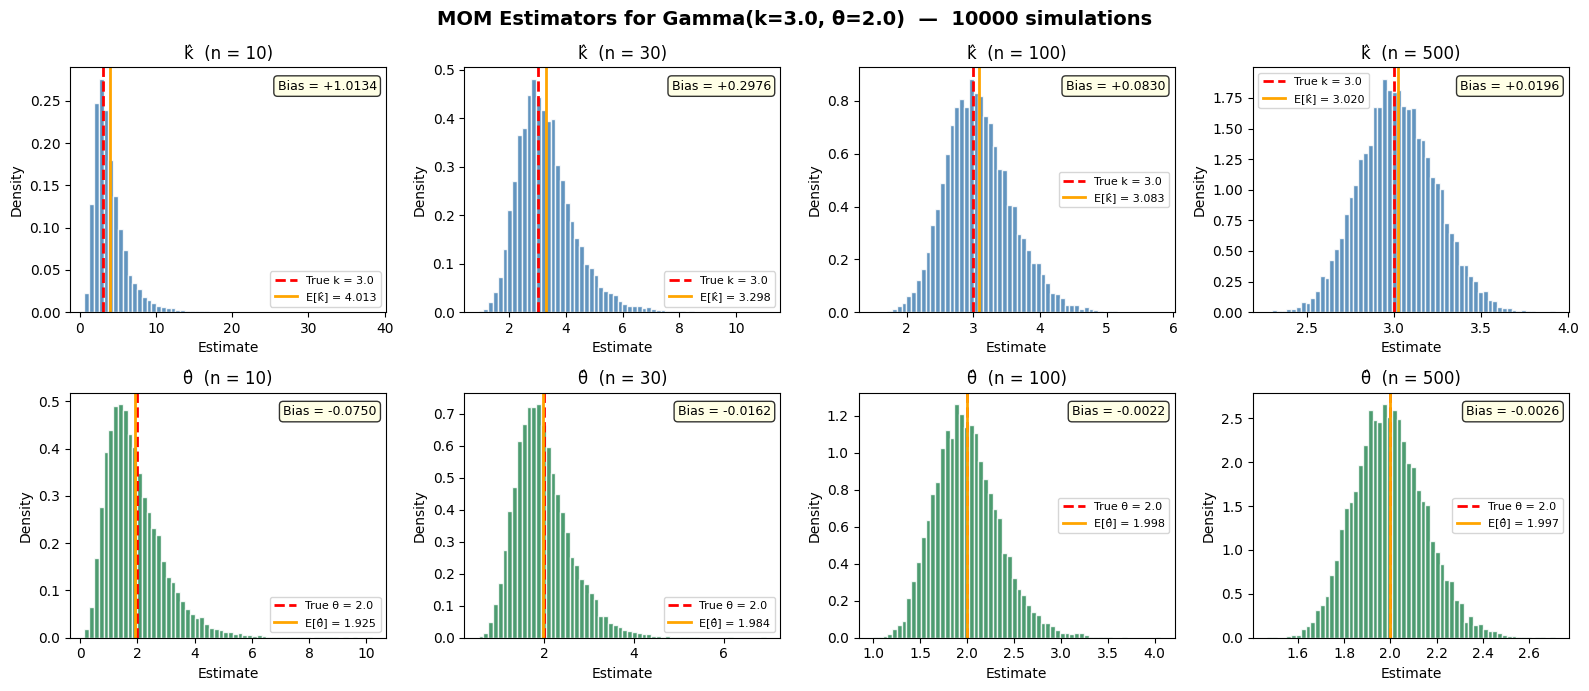

Plot saved as mom_bias_plot.png


In [ ]:
fig, axes = plt.subplots(2, len(sample_sizes), figsize=(16, 7))
fig.suptitle(f'MOM Estimators for Gamma(k={k_true}, θ={theta_true})  —  {n_simulations} simulations',
             fontsize=14, fontweight='bold')

for col, n in enumerate(sample_sizes):
    r = results[n]

    #  k_hat 
    ax = axes[0, col]
    ax.hist(r['k_all'], bins=60, color='steelblue', edgecolor='white', alpha=0.85, density=True)
    ax.axvline(k_true,          color='red',    lw=2, linestyle='--', label=f'True k = {k_true}')
    ax.axvline(r['k_mean'],     color='orange', lw=2, linestyle='-',  label=f'E[k̂] = {r["k_mean"]:.3f}')
    ax.set_title(f'k̂  (n = {n})', fontsize=12)
    ax.set_xlabel('Estimate')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    bias_str = f'Bias = {r["k_bias"]:+.4f}'
    ax.text(0.97, 0.95, bias_str, transform=ax.transAxes,
            ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    # theta_hat
    ax = axes[1, col]
    ax.hist(r['theta_all'], bins=60, color='seagreen', edgecolor='white', alpha=0.85, density=True)
    ax.axvline(theta_true,        color='red',    lw=2, linestyle='--', label=f'True θ = {theta_true}')
    ax.axvline(r['theta_mean'],   color='orange', lw=2, linestyle='-',  label=f'E[θ̂] = {r["theta_mean"]:.3f}')
    ax.set_title(f'θ̂  (n = {n})', fontsize=12)
    ax.set_xlabel('Estimate')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    bias_str = f'Bias = {r["theta_bias"]:+.4f}'
    ax.text(0.97, 0.95, bias_str, transform=ax.transAxes,
            ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('mom_bias_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved as mom_bias_plot.png')

## 5. Bias vs Sample Size Plot

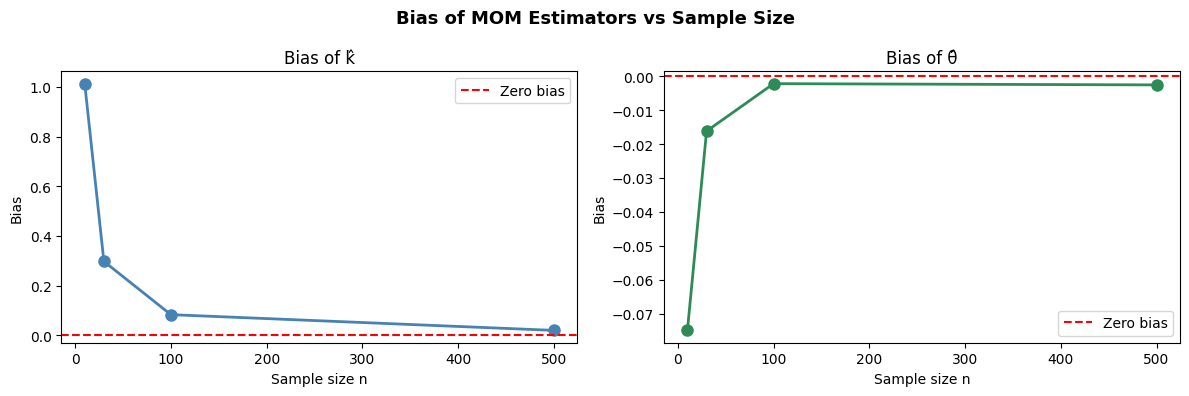

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Bias of MOM Estimators vs Sample Size', fontsize=13, fontweight='bold')

k_biases     = [results[n]['k_bias']     for n in sample_sizes]
theta_biases = [results[n]['theta_bias'] for n in sample_sizes]

axes[0].plot(sample_sizes, k_biases, 'o-', color='steelblue', lw=2, ms=8)
axes[0].axhline(0, color='red', linestyle='--', lw=1.5, label='Zero bias')
axes[0].set_title('Bias of k̂')
axes[0].set_xlabel('Sample size n')
axes[0].set_ylabel('Bias')
axes[0].legend()

axes[1].plot(sample_sizes, theta_biases, 'o-', color='seagreen', lw=2, ms=8)
axes[1].axhline(0, color='red', linestyle='--', lw=1.5, label='Zero bias')
axes[1].set_title('Bias of θ̂')
axes[1].set_xlabel('Sample size n')
axes[1].set_ylabel('Bias')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Conclusion

From the simulation results:

| Estimator | Unbiased? | Notes |
|-----------|-----------|-------|
| $\hat{k} = \bar{x}^2 / s^2$ | **Biased** (small n) | Bias shrinks as $n \to \infty$ — asymptotically unbiased |
| $\hat{\theta} = s^2 / \bar{x}$ | **Biased** (small n) | Bias shrinks as $n \to \infty$ — asymptotically unbiased |